# 2.1 Введение

## Теория 

Говорят, что компьютерная программа обучается при решении какой-то задачи из класса T, если ее производительность, согласно метрике P, улучшается при накоплении опыта E.
Далее в разных сценариях под T, P, и E подразумеваются совершенно разные вещи. 

Среди самых популярных задач T в машинном обучении:


- классификация – отнесение объекта к одной из категорий на основании его признаков
- регрессия – прогнозирование количественного признака объекта на основании прочих его признаков
- кластеризация – разбиение множества объектов на группы на основании признаков этих объектов так, чтобы внутри групп объекты были похожи между собой, а вне одной группы – менее похожи
- детекция аномалий – поиск объектов, "сильно непохожих" на все остальные в выборке либо на какую-то группу объектов
- и много других, более специфичных. Хороший обзор дан в главе "Machine Learning basics" книги "Deep Learning" (Ian Goodfellow, Yoshua Bengio, Aaron Courville, 2016)

Под опытом E понимаются данные (без них никуда), и в зависимости от этого алгоритмы машинного обучения могут быть поделены на те, что обучаются с `учителем` и `без учителя (supervised & unsupervised learning)`. 
- В задачах обучения без учителя имеется выборка, состоящая из объектов, описываемых набором признаков.
- В задачах обучения с учителем вдобавок к этому для каждого объекта некоторой выборки, называемой обучающей, известен целевой признак – по сути это то, что хотелось бы прогнозировать для прочих объектов, не из обучающей выборки.

Пример

Задачи классификации и регрессии – это задачи обучения с учителем. В качестве примера будем представлять задачу кредитного скоринга: на основе накопленных кредитной организацией данных о своих клиентах хочется прогнозировать невозврат кредита. Здесь для алгоритма опыт E – это имеющаяся обучающая выборка: набор объектов (людей), каждый из которых характеризуется набором признаков (таких как возраст, зарплата, тип кредита, невозвраты в прошлом и т.д.), а также целевым признаком. 
- Если этот целевой признак – просто факт невозврата кредита (1 или 0, т.е. банк знает о своих клиентах, кто вернул кредит, а кто – нет), то это задача (бинарной) классификации.
- Если известно, на сколько по времени клиент затянул с возвратом кредита и хочется то же самое прогнозировать для новых клиентов, то это будет задачей регрессии.

Наконец, третья абстракция в определении машинного обучения – это метрика оценки производительности алгоритма P. Такие метрики различаются для разных задач и алгоритмов, и про них мы будим говорить по мере изучения алгоритмов. Пока скажем, что самая простая метрика качества алгоритма, решающего задачу классификации – это доля правильных ответов (accuracy, не называйте ее точностью, этот перевод зарезервирован под другую метрику, precision) – то есть попросту доля верных прогнозов алгоритма на тестовой выборке.


Далее будем говорить о двух задачах обучения с учителем: о классификации и регресcии.

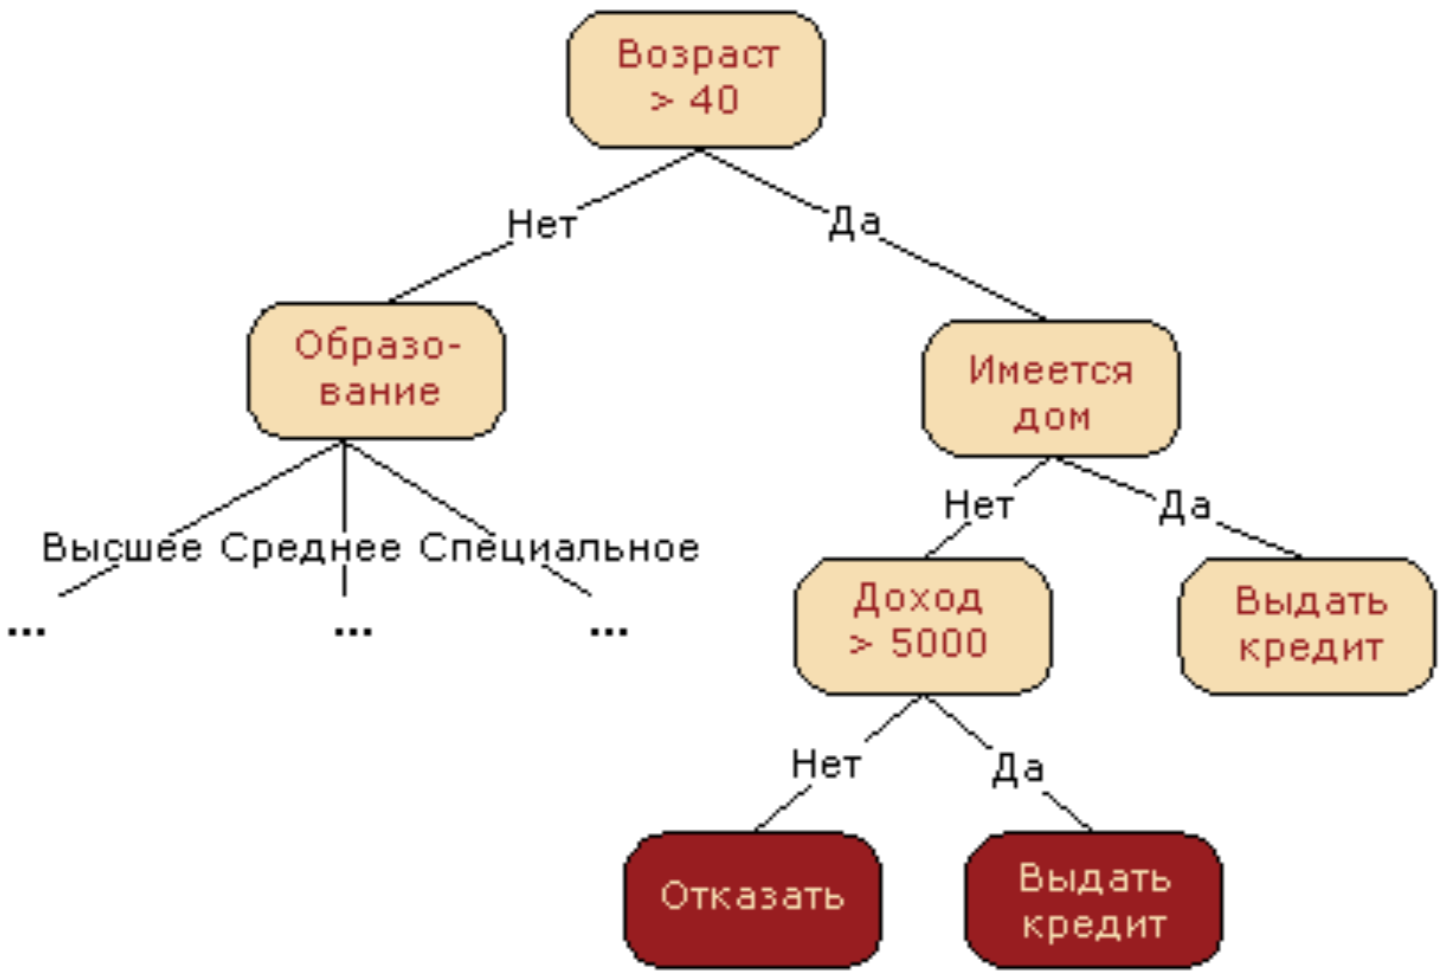

В этом случае можно сказать, что решается задача бинарной классификации (целевой класс имеет два значения: "Выдать кредит" и "Отказать") по признакам "Возраст", "Наличие дома", "Доход" и "Образование".

In [9]:
import sklearn
from sklearn import tree

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
data = pd.DataFrame({
    'X_1': [1, 1, 1, 0, 0, 0, 0, 1],
    'X_2': [0, 0, 0, 1, 0, 0, 0, 1],
    'Y': [1, 1, 1, 1, 0, 0, 0, 0]
})

У нас есть две переменные X_1, X_2 и Y, принимающие значения 0 или 1. То есть их можно воспринимать как некие бинарные номинативные переменные.

Наша с вами задача: научиться при помощи дерева решений предсказывать значения переменной Y, основываясь на значениях переменной X_1 и X_2.

Дерево решений часто сравнивают с тем, как мыслит человек, точнее способ как дерево решений предоставляет некоторые результаты обученной модели. Поэтому давайте сейчас обучим дерево решений в нашей голове.

Посмотрим наши данные.

Если X_1 = 1, то Y чаще всего тоже равно 1. В обратном случае если X_1 = 0, то Y чаще всего тоже равно 0. С X_2 ситуация другая.

Давайте посмотрим как дерево решений справится с этой задачей.

In [12]:
data

,X_1,X_2,Y
0,1,0,1
1,1,0,1
2,1,0,1
3,0,1,1
4,0,0,0
5,0,0,0
6,0,0,0
7,1,1,0


## Создаем объект класса DecisionTreeClassifier

sklearn.tree.DecisionTreeClassifier — это и есть класс  
`Модуль`: sklearn.tree — это папка (пространство имен), где хранится класс.  
`Имя класса`: DecisionTreeClassifier.  

In [15]:
# Здесь мы создаем ОБЪЕКТ (экземпляр класса DecisionTreeClassifier)
# Записываем его в переменную 'clf'

clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy')

# clf - это объект.
# DecisionTreeClassifier() - это вызов конструктора класса для создания объекта.

In [16]:
clf

DecisionTreeClassifier(criterion='entropy')

In [17]:
clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

## Обучаем модель

те данные, которые мы используем для обучения - X  
то, что мы предсказываем - y

In [20]:
X = data[['X_1', 'X_2']]
y = data['Y']

Мы готовы обучить наше первое дерево решений.

Для этого воспользуемся методом fit() и передадим в него переменную с фичами и переменную с целевой переменной (простите за тавтологию).

In [22]:
clf.fit(X = X, y = y)

DecisionTreeClassifier(criterion='entropy')

## Визуализация Decision Tree

[Text(0.5, 0.8333333333333334, 'x[0] <= 0.5\nentropy = 1.0\nsamples = 8\nvalue = [4, 4]'),
 Text(0.25, 0.5, 'x[1] <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [3, 1]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'entropy = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.375, 0.16666666666666666, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.75, 0.5, 'x[1] <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [1, 3]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.875, 0.16666666666666666, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]')]

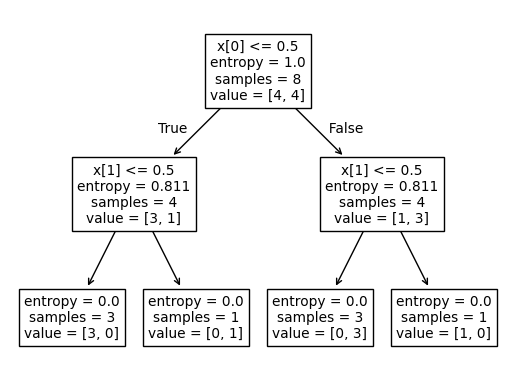

In [24]:
sklearn.tree.plot_tree(clf)

In [25]:
data

,X_1,X_2,Y
0,1,0,1
1,1,0,1
2,1,0,1
3,0,1,1
4,0,0,0
5,0,0,0
6,0,0,0
7,1,1,0


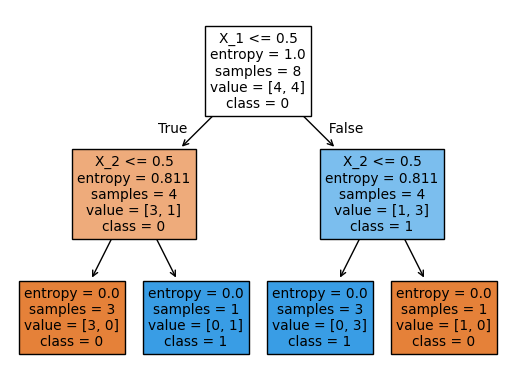

In [26]:
sklearn.tree.plot_tree(clf, feature_names=list(X),
                       class_names=['0', '1'],
                       filled=True);

Так выглядит обученное нами дерево решений. Из графика мы видим, как обученное нами дерево решений научилось разделять наши наблюдения на те, у которых y = 0 и те, у которых y = 1, используя данные про наши переменные X_1 и X_2.

В самом начале у нас верхний белый квадрат - было 4 наблюдения с классом 0, 4 наблюдения с классом 1. Энтропия при этом у нас равна единице, а вопрос, который мы задаём на этом шаге - "Правда ли что X_1 меньше либо равно 0.5?".

И если это правда, т.е. когда X_1 = 0, то мы видим, что у нас преобладает класс 0 (value=[3,1], первое значение - 0, второе - 1). Мы попадаем в левую ветку - 3 наблюдения будут 0 и одно наблюдение - 1.

А вот в обратном случае, т.е. когда X_1 = 1 мы попадаем в правую ветку и у нас преобладает класс 1(value=[1,3]). При этом, 3 наблюдения будут 1 и одно - 0.

Поскольку в квадратах на втором уровне присутствует по 4 значения, относящихся к двум различным группам - дереву решений нужно классифицировать эти оставшиеся значения.

Следующий вопрос, который задаётся - "Правда ли что X_2 меньше либо равно 0.5?".

В этом случае все значения, которые меньше 0.5 попадают в класс 0, а значения больше 0.5 - в класс 1. (для X_1 <= 0.5)

Это позволяет нам безошибочно разделить все наши точки на те, у которых y=0 или y=1.

Осталось только понять как дерево решений это сделало, что за энтропия тут появляется. Она максимальна в самом начале работы алгоритма. И равна нулю когда мы однозначно классифицировали наши наблюдения

Интересно как дерево определило в каком порядке нужно рассматривать фичи, ведь оно выбрало сначала наблюдения X_1 и только потом X_2. А что было бы, если бы фич было не две, а десять?

Оказывается дерево использует интересный математический аппарат, с которым интересно разобраться прежде чем приступать к решению других задач.

# 2.2 Энтропия

## Статья с хабра 

https://habr.com/ru/companies/ods/articles/322534/

## Энтропия

Энтропия Шеннона определяется для системы с $N$ возможными состояниями следующим образом:


$\Large S = -\sum_{i=1}^{N}p_i \log_2{p_i},$


где $p_i$ – вероятности нахождения системы в $i$-ом состоянии. Это очень важное понятие, используемое в физике, теории информации и других областях. Интуитивно, энтропия соответствует степени хаоса в системе. Чем выше энтропия, тем менее упорядочена система и наоборот. Это поможет нам формализовать "эффективное разделение выборки", про которое мы говорили в контексте игры "20 вопросов".

Будем предсказывать цвет шарика по его координате. Конечно, ничего общего с жизнью это не имеет, но позволяет показать, как энтропия используется для построения дерева решений.

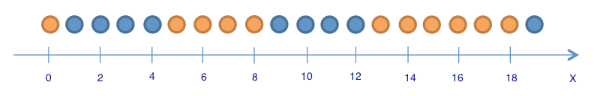

Здесь 9 синих шариков и 11 желтых. Если мы наудачу вытащили шарик, то он с вероятностью $p_1=\frac{9}{20}$ будет синим и с вероятностью $p_2=\frac{11}{20}$ – желтым. Значит, энтропия состояния $S_0 = -\frac{9}{20}\log_2{\frac{9}{20}}-\frac{11}{20}\log_2{\frac{11}{20}} \approx 1$. Само это значение пока ни о чем нам не говорит. Теперь посмотрим, как изменится энтропия, если разбить шарики на две группы – с координатой меньше либо равной 12 и больше 12.

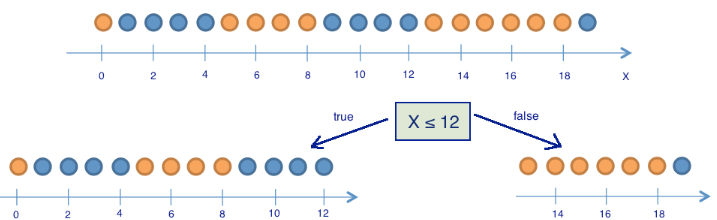

## Information Gain

В левой группе оказалось 13 шаров, из которых 8 синих и 5 желтых. Энтропия этой группы равна $S_1 = -\frac{5}{13}\log_2{\frac{5}{13}}-\frac{8}{13}\log_2{\frac{8}{13}} \approx 0.96$. В правой группе оказалось 7 шаров, из которых 1 синий и 6 желтых. Энтропия правой группы равна $S_2 = -\frac{1}{7}\log_2{\frac{1}{7}}-\frac{6}{7}\log_2{\frac{6}{7}} \approx 0.6$. Как видим, энтропия уменьшилась в обеих группах по сравнению с начальным состоянием, хоть в левой и не сильно. Поскольку энтропия – по сути степень хаоса (или неопределенности) в системе, уменьшение энтропии называют приростом информации. 

Формально прирост информации (information gain, IG) при разбиении выборки по признаку $Q$ (в нашем примере это признак "$x \leq 12$") определяется как


$\Large IG(Q) = S_O - \sum_{i=1}^{q}\frac{N_i}{N}S_i,$


где $q$ – число групп после разбиения, $N_i$ – число элементов выборки, у которых признак $Q$ имеет $i$-ое значение. В нашем случае после разделения получилось две группы ($q = 2$) – одна из 13 элементов ($N_1 = 13$), вторая – из 7 ($N_2 = 7$). 

Прирост информации получился


$ \Large IG(x \leq 12) = S_0 - \frac{13}{20}S_1 - \frac{7}{20}S_2 \approx 0.16.$


Получается, разделив шарики на две группы по признаку "координата меньше либо равна 12", мы уже получили более упорядоченную систему, чем в начале. Продолжим деление шариков на группы до тех пор, пока в каждой группе шарики не будут одного цвета.

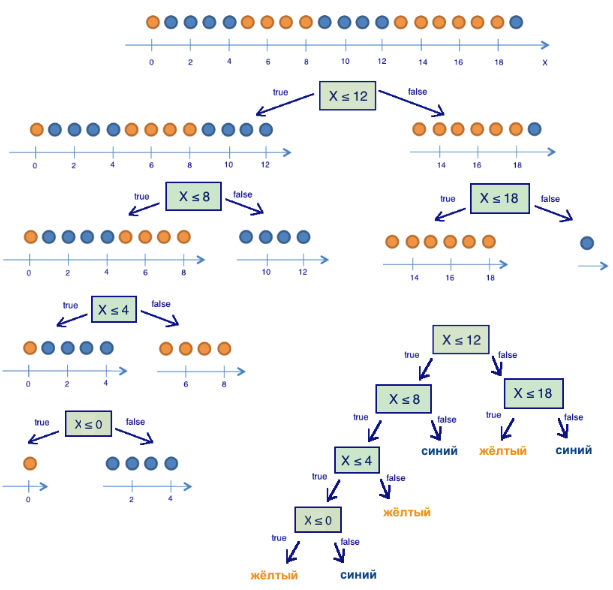

Для правой группы потребовалось всего одно дополнительное разбиение по признаку "координата меньше либо равна 18", для левой – еще три. Очевидно, энтропия группы с шариками одного цвета равна 0 ($\log_2{1} = 0$), что соответствует представлению, что группа шариков одного цвета – упорядоченная.

В итоге мы построили дерево решений, предсказывающее цвет шарика по его координате. 

Отметим, что такое дерево решений может плохо работать для новых объектов (определения цвета новых шариков), поскольку оно идеально подстроилось под обучающую выборку (изначальные 20 шариков). Для классификации новых шариков лучше подойдет дерево с меньшим числом "вопросов", или разделений, пусть даже оно и не идеально разбивает по цветам обучающую выборку. Эту проблему, переобучение, мы еще рассмотрим далее.

## Наш пример

In [40]:
data

,X_1,X_2,Y
0,1,0,1
1,1,0,1
2,1,0,1
3,0,1,1
4,0,0,0
5,0,0,0
6,0,0,0
7,1,1,0


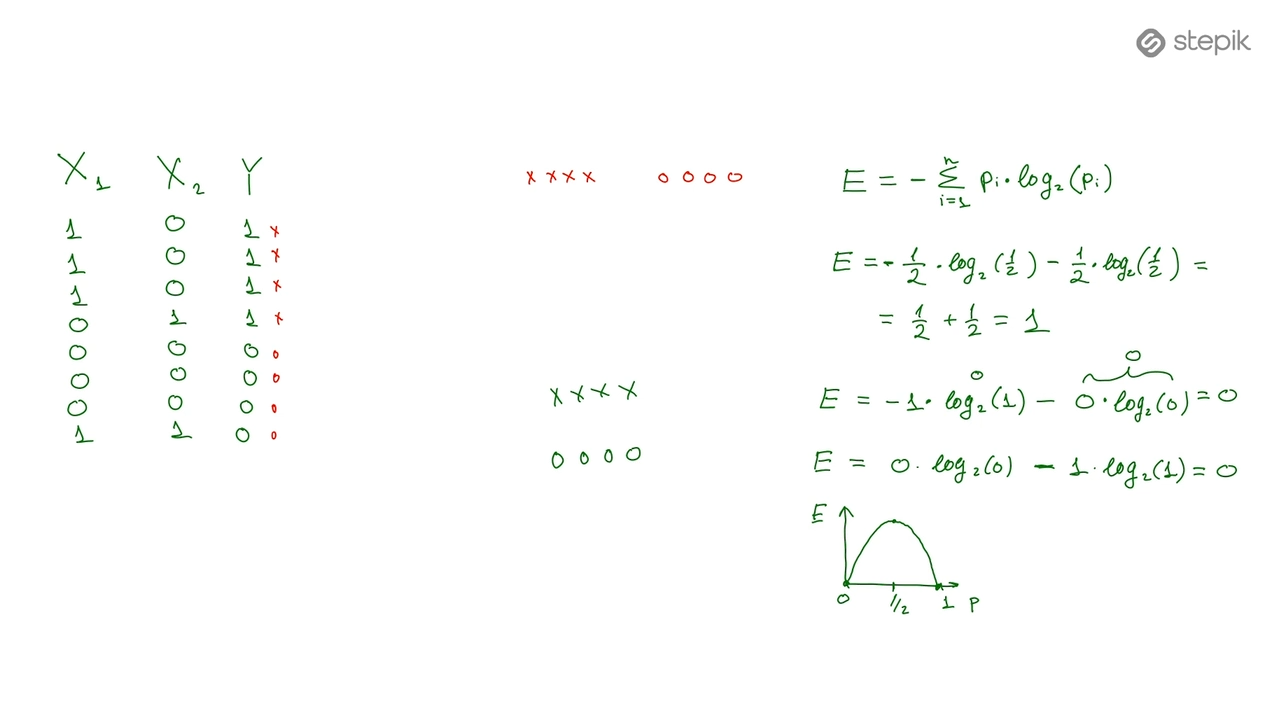

Здесь представлена формула энтропии для Y (без переменных X_1 и X_2). xxxx и оооо - состояние полной определенности (энтропия равна 0)

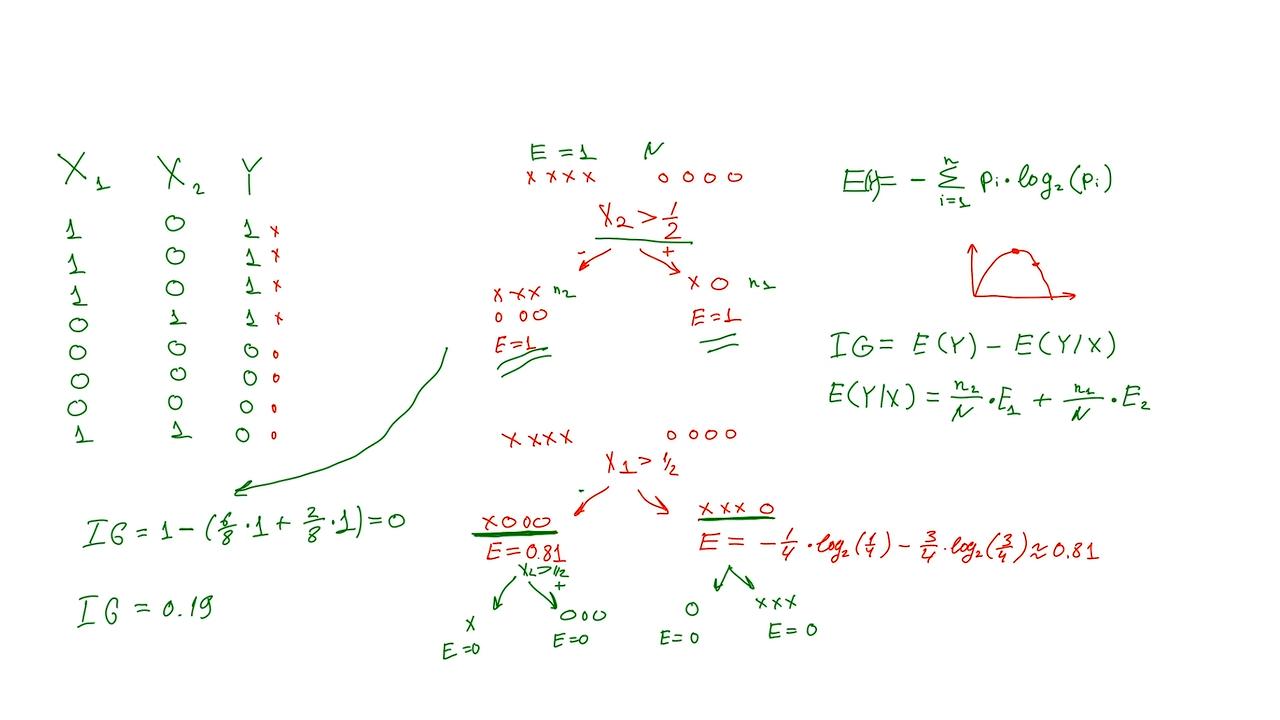

Здесь объясняется включение переменных X_2 и X_1. Как дерево решений понимает по какой переменной рассплититься сначала. Оно делит сначала по X_2 и считает энтропию (равна 1) и по X_1 (энтропия равна 0.81, что лучше чем X_2). Также считает IG (прирост информации), который выше у X_1. Поэтому сачала идет сплит по X_1. Потом идет сплит по X_2, пока не будет полной определенности.

## Задания

In [46]:
cats = pd.read_csv('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/cats.csv', index_col=0)

In [47]:
cats

,Шерстист,Гавкает,Лазает по деревьям,Вид
0,1,1,0,собачка
1,1,1,0,собачка
2,1,1,0,собачка
3,1,1,0,собачка
4,1,0,1,котик
5,1,0,1,котик
6,1,0,1,котик
7,1,0,1,котик
8,1,1,1,котик
9,0,0,1,котик


$\Large S = -\sum_{i=1}^{N}p_i \log_2{p_i},$

Энтропия при разделении по фиче Шерстист в группах, где Шерстист равно 0 и 1 соответственно

In [50]:
E_0 = -1/1*np.log2(1/1) - 0*np.log2(0)
E_0 

C:\Users\ryagu\AppData\Local\Temp\ipykernel_2736\3801195303.py:1: RuntimeWarning: divide by zero encountered in log2
  E_0 = -1/1*np.log2(1/1) - 0*np.log2(0)
C:\Users\ryagu\AppData\Local\Temp\ipykernel_2736\3801195303.py:1: RuntimeWarning: invalid value encountered in scalar multiply
  E_0 = -1/1*np.log2(1/1) - 0*np.log2(0)


nan

In [51]:
E_1 = -5/9*np.log2(5/9) - 4/9*np.log2(4/9) 
E_1

0.9910760598382222

Энтропия при разделении по фиче Гавкает в группах, где Гавкает равно 0 и 1 соответственно,

In [53]:
E_0 = -5/5*np.log2(5/5) - 0/5*np.log2(0/5) 
E_0

C:\Users\ryagu\AppData\Local\Temp\ipykernel_2736\3089616818.py:1: RuntimeWarning: divide by zero encountered in log2
  E_0 = -5/5*np.log2(5/5) - 0/5*np.log2(0/5)
C:\Users\ryagu\AppData\Local\Temp\ipykernel_2736\3089616818.py:1: RuntimeWarning: invalid value encountered in scalar multiply
  E_0 = -5/5*np.log2(5/5) - 0/5*np.log2(0/5)


nan

In [54]:
E_1 = -4/5*np.log2(4/5) - 1/5*np.log2(1/5) 
E_1

0.7219280948873623

Энтропия при разделении по фиче Лазает по деревьям в группах, где эта фича равна 0 и 1

In [56]:
E_0 = 0
E_0

0

In [57]:
E_1 = 0
E_1

0

Ещё немного арифметики - посчитаем Information Gain по данным из предыдущего задания. Впишите через пробел округлённые до 2-ого знака значения IG для фичей Шерстист, Гавкает и Лазает по деревьям. Десятичным разделителем в данном задании является точка.

$\Large IG(Q) = S_O - \sum_{i=1}^{q}\frac{N_i}{N}S_i,$  
где $q$ – число групп после разбиения, $N_i$ – число элементов выборки, у которых признак $Q$ имеет $i$-ое значение

Шерстист

In [61]:
E_Y = -4/10*np.log2(4/10) - 6/10*np.log2(6/10) 
E_Y

0.9709505944546686

In [62]:
IG_0 = E_Y - ((1/10*0) +(9/10*0.99))
IG_0

0.07995059445466857

Гавкает

In [64]:
IG_1 = E_Y - ((5/10*0) +(5/10*0.72))
IG_1

0.6109505944546686

Лазает по деревьям

In [66]:
IG_2 = E_Y - ((4/10*0) +(6/10*0))
IG_2 

0.9709505944546686

# 2.3 ML Titanic

## Первая попытка

In [69]:
import zipfile

- survival - Survival	0 = No, 1 = Yes
- pclass - Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
- sex	- Sex	
- Age	- Age in years	
- sibsp - of siblings / spouses aboard the Titanic (Количество братьев/сестер и супругов на борту Титаника)
- parch - of parents / children aboard the Titanic (Количество родителей и детей на борту Титаника)
- ticket - Ticket number	
- fare - Passenger fare	(плата за проезд)
- cabin	- Cabin number	
- embarked	- Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

In [71]:
with zipfile.ZipFile('titanic.zip') as z:
    with z.open('train.csv') as f: # specify exact path inside ZIP
        df = pd.read_csv(f)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [72]:
df.shape

(891, 12)

In [73]:
df.isna().mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [74]:
X = df.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'], axis=1)

In [75]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [76]:
X = pd.get_dummies(X, dtype=int)
X

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,38.0,1,0,71.2833,1,0,1,0,0
2,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,0,1,0,0,1
887,1,19.0,0,0,30.0000,1,0,0,0,1
888,3,NaN,1,2,23.4500,1,0,0,0,1
889,1,26.0,0,0,30.0000,0,1,1,0,0


In [77]:
X['Age'].median()

28.0

In [78]:
X['Age'] = X['Age'].fillna(X['Age'].median())

In [79]:
y = df['Survived']

In [80]:
clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy')

In [81]:
clf

DecisionTreeClassifier(criterion='entropy')

In [82]:
clf.fit(X, y)

DecisionTreeClassifier(criterion='entropy')

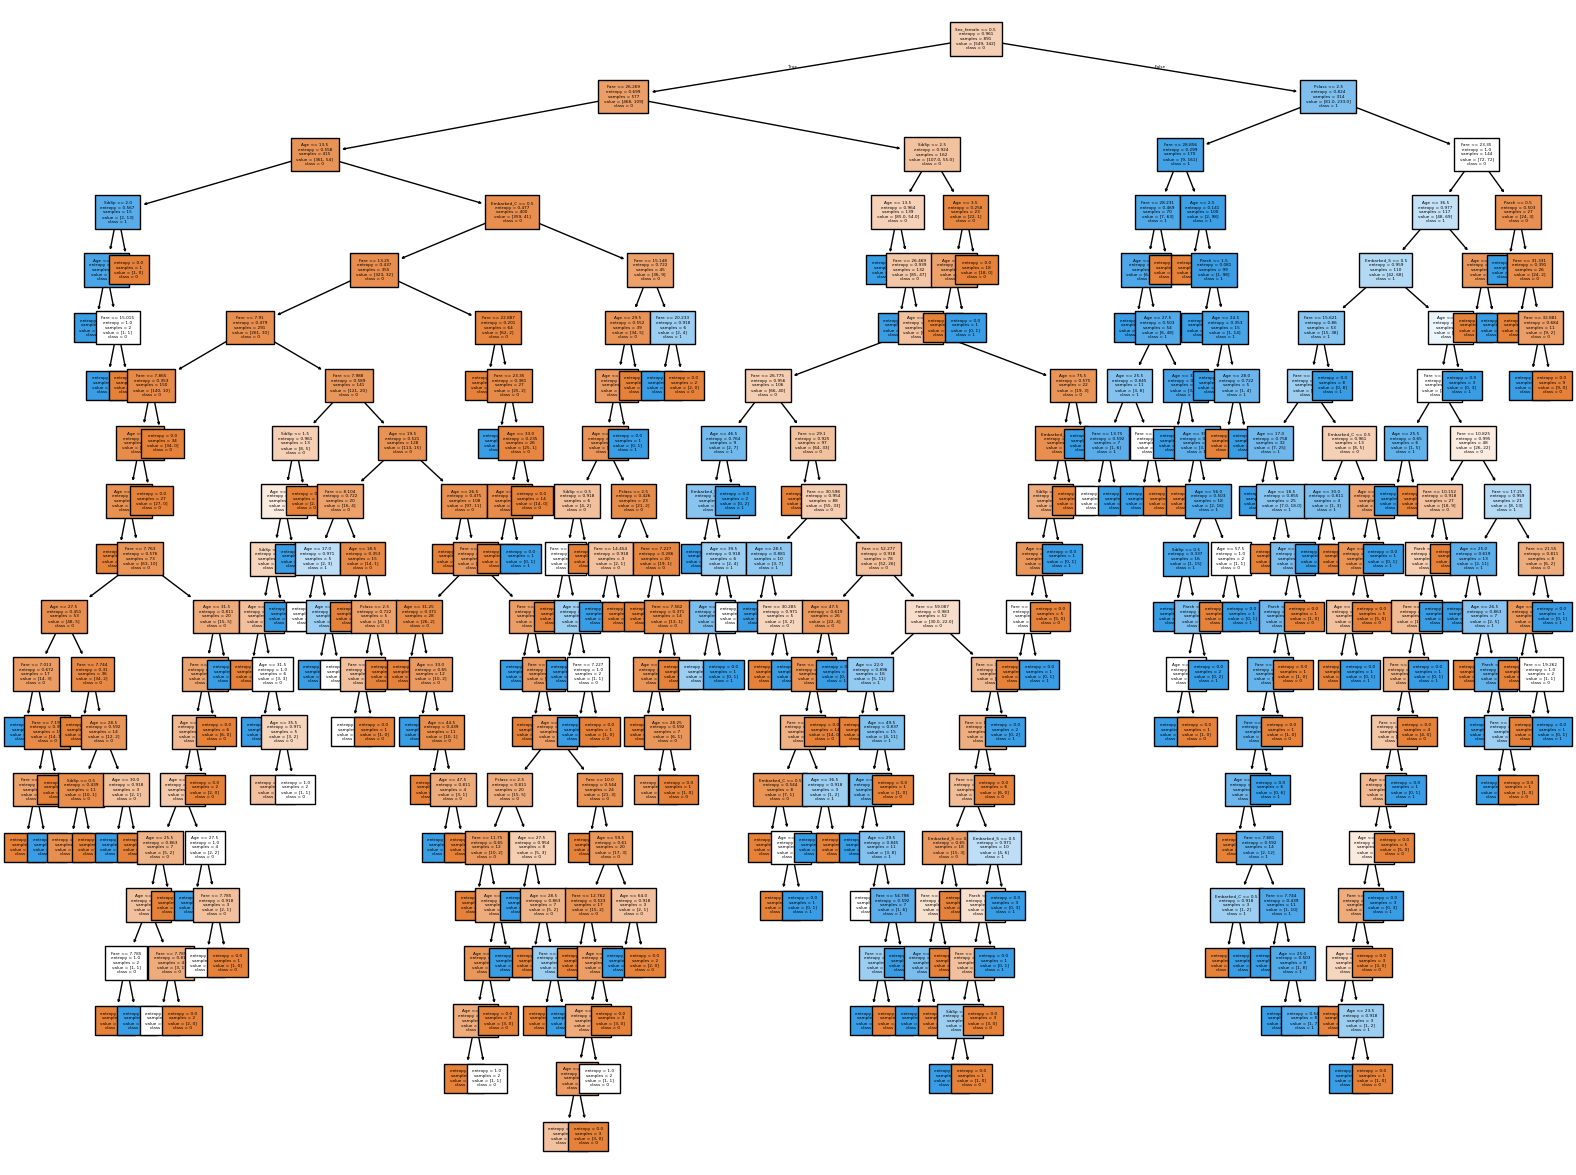

In [83]:
plt.figure(figsize=(20,15))
sklearn.tree.plot_tree(clf, feature_names=list(X),
                       class_names=['0', '1'], #1 - survived
                       filled=True,
                       fontsize=3
                       );

## Объяснение

Итак, разберёмся с тем - почему наше дерево получилось таким глубоким.

В нашем классификаторе есть параметр max_depth, который в нашем примере задан как None, т.е. наше дерево может расти сколько угодно.

Почему же это привело к таким результатам?

Когда мы говорим об общей закономерности, нам зачастую не так важно добиться 100% точности классификации, потому что в большинстве случаев, когда мы говорим про реальные задачи классификации у нас бывают такие ситуации:

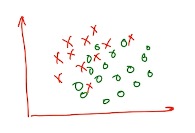

Есть два класса, между ними можно провести разделительную поверхность, но у нас довольно часто, просто в силу того, что никогда не бывает идеальной 100% точности, никогда нельзя ожидать, что два класса будут разделены 100%-но.

То есть для реального мира вот такое разделение было бы хорошим, максимально правильным решением.
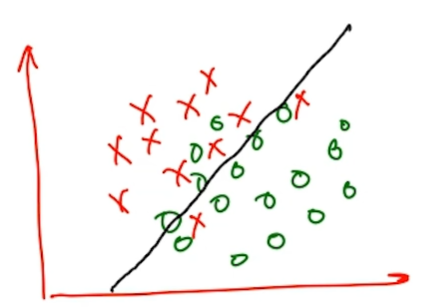

А вот заниматься выискиванием стопроцентного описания каждой такой отдельной ситуации - неправильно. Поскольку наша кривая, описывала бы отлично только одну выборку данных, а для другой выборки уже пришлось бы описывать новую кривую. А примерное решение, допускающее небольшую ошибку достаточно хорошо разделила бы классы и на новых данных.


Это и называется переобучением. Когда вместо того чтобы вычленить какую-то более общую закономерность мы занимаемся тем, что пытаемся безошибочно классифицировать каждое наблюдение в нашей выборке. Что далеко не всегда является необходимостью.

## Делаем правильно

In [90]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,38.0,1,0,71.2833,1,0,1,0,0
2,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,0,1


In [91]:
from sklearn.model_selection import train_test_split

In [92]:
#random_state=42            
#при передаче параметров функции train_test_split означает, что мы фиксируем состояние случайного разбиения 
#(чтобы результат был воспроизводимым у других людей)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [93]:
# на которой обучаем
X_train.shape

(596, 10)

In [94]:
# на которой проверяем
X_test.shape

(295, 10)

Проверить это можно сравнив насколько хорошо наше дерево предсказывает правильные ответы на обучающей выборке(train множестве) и насколько хорошо - на тестовой. Это очень упрощённая версия валидации модели.

У классификатора есть метод score, предсказывающий число правильных ответов.

In [96]:
clf.score(X, y)

0.9797979797979798

Возьмём наш классификатор и обучим его на обучающей выборке.

In [98]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

Посмотрим какая у нас точность предсказания на обучающей выборке

In [100]:
clf.score(X_train, y_train)

0.9798657718120806

А теперь посмотрим на тестовой выборке, на тех данных, которые наш классификатор не видел.

In [102]:
clf.score(X_test, y_test)

0.7694915254237288

Ограничим глубину дерева:

In [104]:
clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [105]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [106]:
clf.score(X_train, y_train)

0.8238255033557047

In [107]:
clf.score(X_test, y_test)

0.8203389830508474

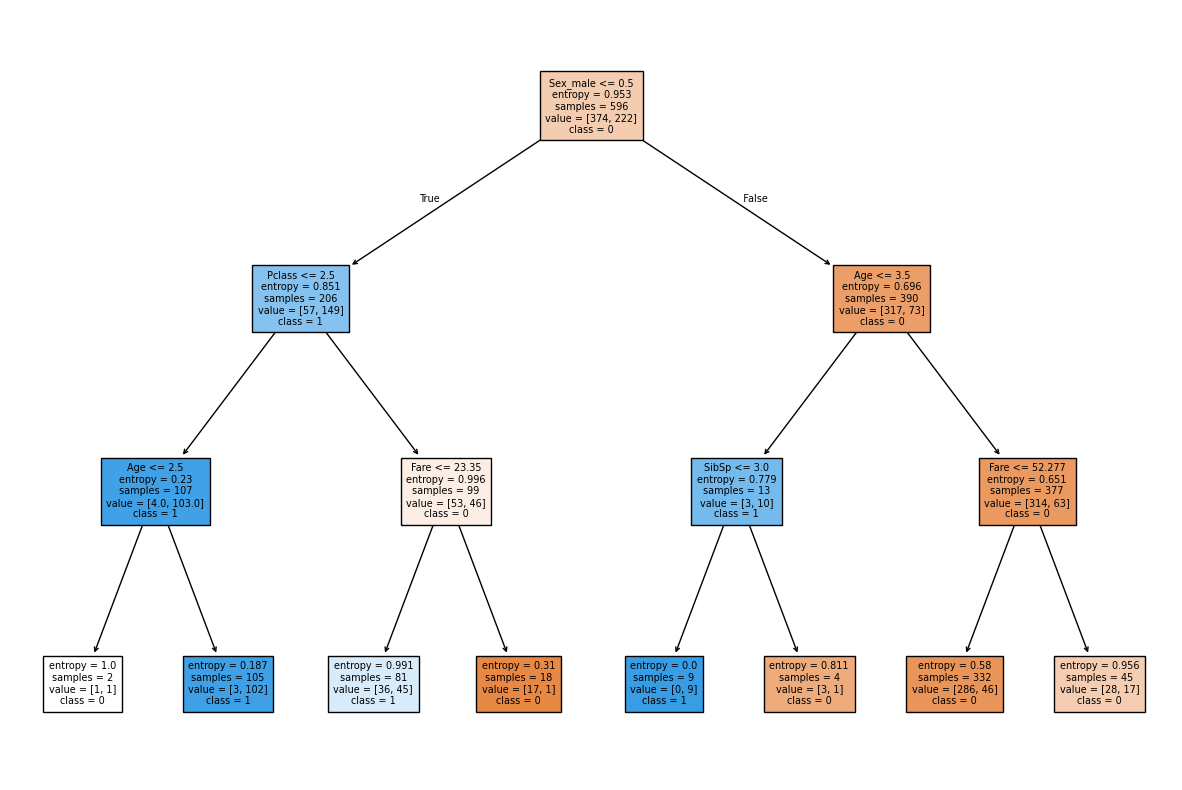

In [108]:
plt.figure(figsize=(15,10))
sklearn.tree.plot_tree(clf, feature_names=list(X),
                       class_names=['0', '1'], #1 - survived
                       filled=True,
                       fontsize=7
                       );

# 2.4 Обучение, переобучение, недообучение и кросвалидация

## train и test

In [111]:
max_depth_values = range(1, 101)

In [112]:
scores_list = []

In [113]:
for max_depth in max_depth_values:
    clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy', max_depth=max_depth)
    clf.fit(X_train, y_train)
    train_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)
    
    temp_list = (max_depth, train_score, test_score)
    scores_list.append(temp_list)

scores_data = pd.DataFrame(scores_list, columns=['max_depth', 'train_score', 'test_score'])

In [114]:
scores_data

,max_depth,train_score,test_score
0,1,0.781879,0.796610
1,2,0.805369,0.776271
2,3,0.823826,0.820339
3,4,0.833893,0.823729
4,5,0.840604,0.810169
...,...,...,...
95,96,0.979866,0.776271
96,97,0.979866,0.769492
97,98,0.979866,0.766102
98,99,0.979866,0.772881


<Axes: xlabel='max_depth', ylabel='train_score'>

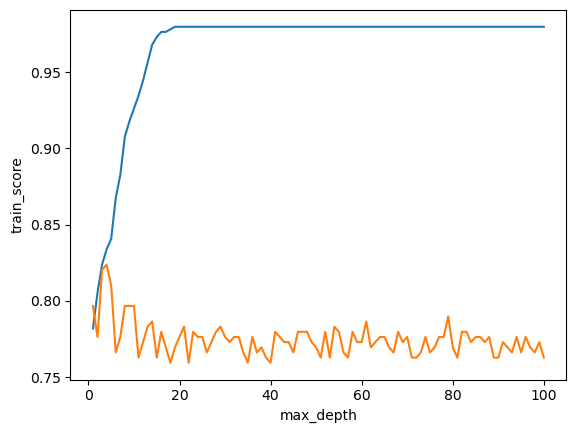

In [115]:
sns.lineplot(data=scores_data, x = 'max_depth', y = 'train_score')
sns.lineplot(data=scores_data, x = 'max_depth', y = 'test_score')
#plt.xlim(0,20)

train score:
- растет с увеличением глубины дерева
- что не всегда ведет к нахождению общих закономерностей в исследуемых данных

test score:
- изначально невелик (модель еще не доучилась)
- на промежутке 3-5 score максимален (оптимальное состояние: закономерность с изученных данных переносится на новые)
- с дальнейшим увеличением глубины test score начинает падать (переход от недообученности к переобученности)

## Кроссвалидация

Конкретно модель конечно же не учится на тестовой выборке. Но на тестовой выборке мы подбираем параметры, "оптимальные" для обучения модели. И когда тестовая выборка одна и та же для всех параметров, то выбранные "лучшие" параметры по сути являются лучшими только для конкретной тестовой выборки, а не для всех возможных данных в целом. Т.е. итоговая модель хорошо обобщает не все закономерности данных, а только закономерности, предоставленные в конкретной обучающей и конкретной тестовой выборках, а это аналогично переобучению.

Т.е. мы делим данные на обучающую и тестовую выборки. Обучаем модель, смотрим train_score, test_score. Допустим, видим, что test_score плохой, возвращаемся к подбору параметров, настраиваем параметры. Снова обучаем модель и даем тот же самый тестовый набор. Таким образом модель будет подстраиваться под этот тестовый набор. И наша модель может хорошо подходить именно для x_test_data, но для других оказаться переобученной и не настолько эффективной.

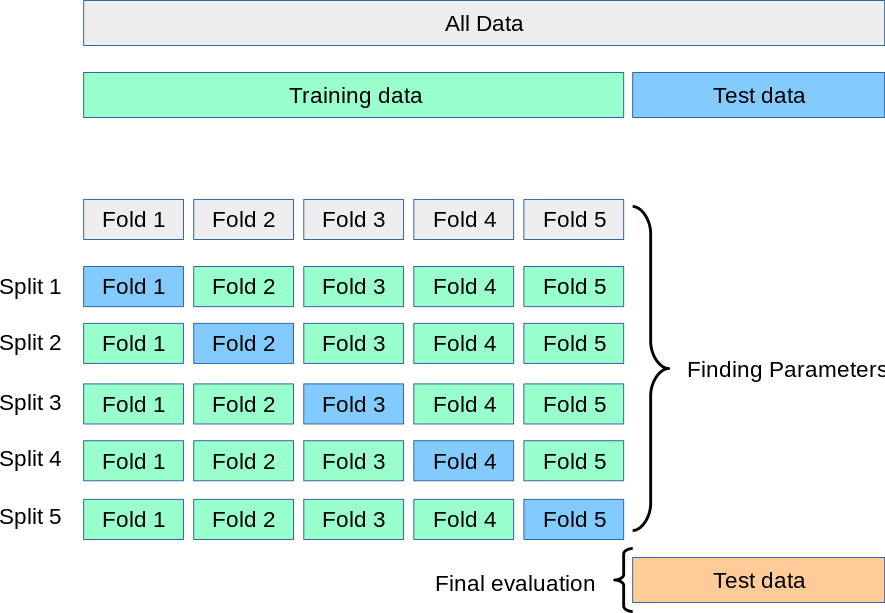

In [121]:
from sklearn.model_selection import cross_val_score

In [122]:
clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy', max_depth=4)

Здесь cross_val_score разбивает условно X_train и y_train на 5 выборок (как выше на скрине). Fold1 (например 200 X_train и y_train при 1000 наблюдений) идет на тестовую выборку. Остальное на трэйн. И так 5 раз.

In [124]:
cross_val_score(clf, X_train, y_train, cv = 5)

array([0.76666667, 0.82352941, 0.78991597, 0.75630252, 0.80672269])

In [125]:
# средняя точность на кросс-валидации
cross_val_score(clf, X_train, y_train, cv = 5).mean()

0.7886274509803922

Возвращаемся к работе с циклом для поиска оптимальной глубины и добавляем в scores_data среднюю точность на кросс-валидации.

In [127]:
max_depth_values = range(1, 101)

In [128]:
scores_list = []

In [129]:
for max_depth in max_depth_values:
    clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy', max_depth=max_depth)
    clf.fit(X_train, y_train)
    train_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)
    val_score = cross_val_score(clf, X_train, y_train, cv = 5).mean()
    
    temp_list = (max_depth, train_score, test_score, val_score)
    scores_list.append(temp_list)

scores_data = pd.DataFrame(scores_list, columns=['max_depth', 'train_score', 'test_score', 'val_score'])

 В результате получим датафрейм с колонкой  max_depth и тремя  score

In [131]:
scores_data

,max_depth,train_score,test_score,val_score
0,1,0.781879,0.796610,0.781961
1,2,0.805369,0.776271,0.770196
2,3,0.823826,0.820339,0.790322
3,4,0.833893,0.823729,0.788627
4,5,0.840604,0.810169,0.802073
...,...,...,...,...
95,96,0.979866,0.769492,0.770182
96,97,0.979866,0.779661,0.766821
97,98,0.979866,0.776271,0.768501
98,99,0.979866,0.779661,0.768501


<Axes: xlabel='max_depth', ylabel='train_score'>

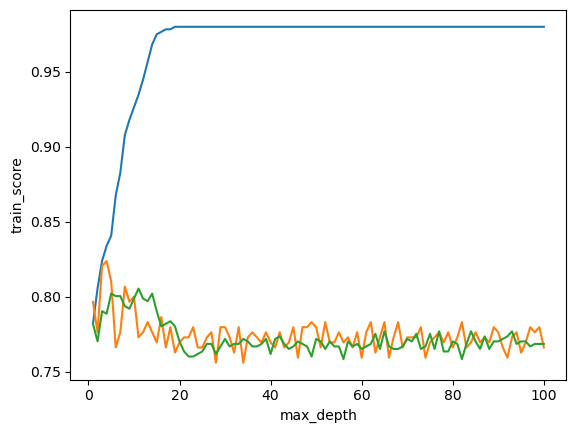

In [132]:
sns.lineplot(data=scores_data, x = 'max_depth', y = 'train_score')
sns.lineplot(data=scores_data, x = 'max_depth', y = 'test_score')
sns.lineplot(data=scores_data, x = 'max_depth', y = 'val_score')
#plt.xlim(0,20)

Смотрим на зеленую линию (cross_val_score ). На графике ясно видно, что максимум приходится на глубину до 20.

In [134]:
max_val_score = scores_data['val_score'].max()

In [135]:
scores_data.query('val_score == @max_val_score')

,max_depth,train_score,test_score,val_score
10,11,0.934564,0.772881,0.805392


Максимальный val_score достигается при глубине дерева (max_depth = 10)

Создаем классификатор, указывая соответствующее значение аргумента  max_depth. Обучаем на тренировочной выборке и замеряем точность на тестовой.

In [138]:
best_clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy', max_depth=10)

In [139]:
best_clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10)

In [140]:
best_clf.score(X_test, y_test)

0.7966101694915254

## Выводы

В сухом остатке - тезисы:

1) точность (score) как процент правильных ответов не хорошая и не верная метрика качества модели. Например, в ситуации, когда только 10% выживших, любая модель-классификатор , которая бы всем (этот говорящий пример назовем "чтоб все сдохли") предсказывала, что они не выживут, давала бы точность 90% , так как 10% выживших здесь, по сути, погрешность, равная доле неправильно классифицированных.

2) точность хорошо работает на сбалансированных выборках, т.е. когда равномерное распределение между классами

3) получается, точность как доля верно классифицированных может быть разной для разных классов

4) двигаемся дальше - узнаем новые методы оценки качества модели (кто-то об этом уже подумал до нас).

5) Точность это процент ошибки, т.е. процент несовпавших предсказанных ответов с ответами из тестовой выборки.

## Заданиe 1

In [144]:
train_iris = pd.read_csv('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/train_iris.csv', index_col=0)

In [145]:
train_iris.head()

,sepal length,sepal width,petal length,petal width,species
130,7.4,2.8,6.1,1.9,2
7,5.0,3.4,1.5,0.2,0
11,4.8,3.4,1.6,0.2,0
142,5.8,2.7,5.1,1.9,2
109,7.2,3.6,6.1,2.5,2


In [146]:
X_train = train_iris.iloc[:, :-1]
y_train = train_iris['species']

In [147]:
test_iris = pd.read_csv('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/test_iris.csv', index_col=0)

In [148]:
test_iris.head()

,sepal length,sepal width,petal length,petal width,species
114,5.8,2.8,5.1,2.4,2
70,5.9,3.2,4.8,1.8,1
138,6.0,3.0,4.8,1.8,2
59,5.2,2.7,3.9,1.4,1
44,5.1,3.8,1.9,0.4,0


In [149]:
X_test = test_iris.iloc[:, :-1]
y_test = test_iris['species']

In [150]:
max_depth_values = range(1, 101)

In [151]:
scores_list = []

In [152]:
np.random.seed(0)
for max_depth in max_depth_values:
    clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy', max_depth=max_depth)
    clf.fit(X_train, y_train)
    train_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)
    
    temp_list = (max_depth, train_score, test_score)
    scores_list.append(temp_list)

scores_data = pd.DataFrame(scores_list, columns=['max_depth', 'train_score', 'test_score'])

In [153]:
scores_data

,max_depth,train_score,test_score
0,1,0.70,0.60
1,2,0.97,0.94
2,3,0.99,0.94
3,4,1.00,0.92
4,5,1.00,0.92
...,...,...,...
95,96,1.00,0.92
96,97,1.00,0.92
97,98,1.00,0.94
98,99,1.00,0.92


<Axes: xlabel='max_depth', ylabel='train_score'>

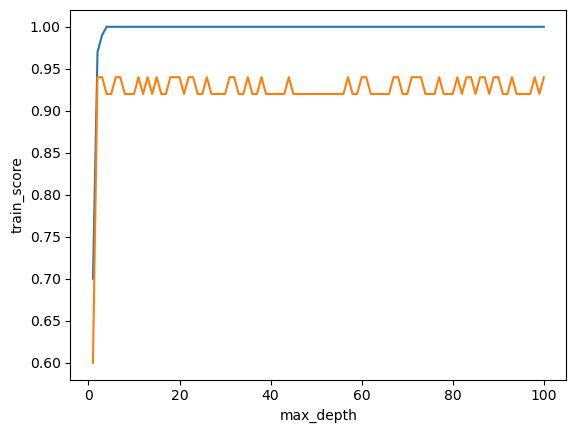

In [154]:
sns.lineplot(data=scores_data, x = 'max_depth', y='train_score')
sns.lineplot(data=scores_data, x = 'max_depth', y='test_score')

## Задание 2

### Загружаем данные

In [157]:
train = pd.read_csv('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/dogs_n_cats.csv')

In [158]:
train.head()

,Длина,Высота,Шерстист,Гавкает,Лазает по деревьям,Вид
0,15,18.0,1,1,0,собачка
1,20,24.0,1,0,0,собачка
2,34,40.8,1,1,0,собачка
3,26,31.2,1,1,0,собачка
4,16,19.2,1,1,0,собачка


In [159]:
train.shape

(1000, 6)

### Выделяем зависимую и независимые переменные

In [161]:
X = train.iloc[:, :-1]
y = train['Вид']

In [162]:
X.head()

,Длина,Высота,Шерстист,Гавкает,Лазает по деревьям
0,15,18.0,1,1,0
1,20,24.0,1,0,0
2,34,40.8,1,1,0
3,26,31.2,1,1,0
4,16,19.2,1,1,0


In [163]:
y.head()

0    собачка
1    собачка
2    собачка
3    собачка
4    собачка
Name: Вид, dtype: object

In [164]:
print(X.shape)
print(y.shape)

(1000, 5)
(1000,)


### Загружаем данные для предсказания

In [166]:
# оставляем для предсказания
test = pd.read_json('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/dataset_209691_15 (1).txt')

In [167]:
test.head()

,Длина,Высота,Шерстист,Гавкает,Лазает по деревьям
0,18,21.6,1,0,0
1,24,28.8,1,1,0
2,26,31.2,1,1,0
3,25,30.0,1,1,0
4,30,36.0,1,1,0


In [168]:
test.shape

(100, 5)

### Делим данные на обучающую и тестовую выборки

In [170]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Ищем лучшую глубину дерева

In [172]:
max_depth_values = range(1, 101)
scores_list = []

for max_depth in max_depth_values:
    # создаем классификатор
    clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy', max_depth=max_depth)
    # обучаем на обучающей выборке
    clf.fit(X_train, y_train)
    # считаем точность на обучающей выборке
    train_score = clf.score(X_train, y_train)
    # считаем точность на тестовой выборке
    test_score = clf.score(X_test, y_test)
    # считаем среднюю точность на кросс-валидации
    val_score = cross_val_score(clf, X_train, y_train, cv = 5).mean()
    
    temp_list = (max_depth, train_score, test_score, val_score)
    scores_list.append(temp_list)

scores_data = pd.DataFrame(scores_list, columns=['max_depth', 'train_score', 'test_score', 'val_score'])

In [173]:
scores_data

,max_depth,train_score,test_score,val_score
0,1,1.0,1.0,1.0
1,2,1.0,1.0,1.0
2,3,1.0,1.0,1.0
3,4,1.0,1.0,1.0
4,5,1.0,1.0,1.0
...,...,...,...,...
95,96,1.0,1.0,1.0
96,97,1.0,1.0,1.0
97,98,1.0,1.0,1.0
98,99,1.0,1.0,1.0


<Axes: xlabel='max_depth', ylabel='train_score'>

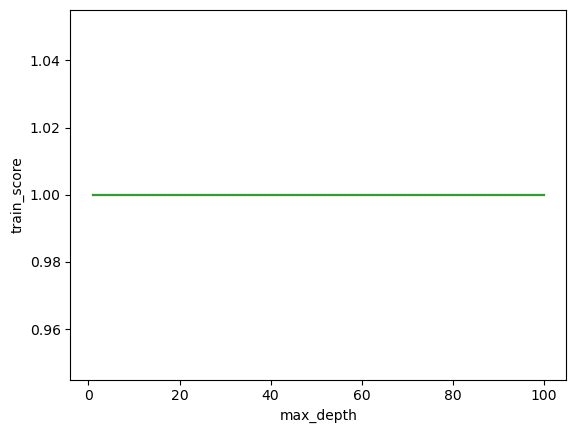

In [174]:
sns.lineplot(data=scores_data, x = 'max_depth', y = 'train_score')
sns.lineplot(data=scores_data, x = 'max_depth', y = 'test_score')
sns.lineplot(data=scores_data, x = 'max_depth', y = 'val_score')

### Создаем классификатор на лучших параметрах

In [176]:
best_clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy', max_depth=3) # 3 - просто так, потому что все одинаково

### Обучаем модель

In [178]:
best_clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [179]:
best_clf.score(X_train, y_train)

1.0

In [180]:
best_clf.score(X_test, y_test)

1.0

### Предсказываем на новом наборе данных

In [182]:
best_clf.predict(X=test)

array(['собачка', 'собачка', 'собачка', 'собачка', 'собачка', 'собачка',
       'собачка', 'собачка', 'собачка', 'собачка', 'собачка', 'собачка',
       'собачка', 'собачка', 'собачка', 'собачка', 'собачка', 'собачка',
       'собачка', 'собачка', 'собачка', 'собачка', 'собачка', 'собачка',
       'собачка', 'собачка', 'собачка', 'собачка', 'собачка', 'собачка',
       'собачка', 'собачка', 'собачка', 'собачка', 'собачка', 'собачка',
       'собачка', 'собачка', 'собачка', 'собачка', 'собачка', 'собачка',
       'собачка', 'котик', 'котик', 'котик', 'котик', 'котик', 'котик',
       'котик', 'котик', 'котик', 'котик', 'котик', 'котик', 'котик',
       'котик', 'котик', 'котик', 'котик', 'котик', 'котик', 'котик',
       'котик', 'котик', 'котик', 'котик', 'котик', 'котик', 'котик',
       'котик', 'котик', 'котик', 'котик', 'котик', 'котик', 'котик',
       'котик', 'котик', 'котик', 'котик', 'котик', 'котик', 'котик',
       'котик', 'котик', 'котик', 'котик', 'котик', 'котик', 'котик

In [183]:
y_predict = pd.DataFrame(best_clf.predict(X=test))

In [184]:
y_predict.value_counts()

0      
котик      57
собачка    43
Name: count, dtype: int64

# 2.5 Метрики качества модели

В этом уроке мы поговорим про метрики качества. Метрики, при помощи которых мы можем понять насколько хорошо наша модель справляется с задачей классификации.

Как мы уже поняли, метрика accuracy - т.е. общий процент правильных ответов зачастую бесполезна и, более того, может нас вводить в заблуждение. Наприме, в ситуации предсказания drop out онлайн курса на степике точность модели в 90% на самом деле возможно нам ни о чём не говорит.

Если бы наша модель всем слушателям проставила 0 (что они не закончат курс), то в среднем ожидаемое accuracy было бы как раз 90%. Соответственно, нам важно понимать не только в среднем процент правильных ответов высокий или низкий, но и насколько хорошо наша модель справляется с правильностью классификации именно внутри каждого из классов, насколько хорошо она умеет находить тех, кто имеет положительный класс среди всех пользователей, насколько хорошо она умеет отделять их от пользователей отрицательного класса и насколько внутри отрицательного класса тоже у нас получается отделять их от других пользователей.

Мы познакомимся с двумя метриками. Базовыми и важными понятиями при любой задаче классификации - Precision и Recall и потом разберём более комплексную метрику - f-мера.

Познакомимся с тем, что же такое precision и recall. В этом нам помогут концепции ошибок первого и второго рода и возможные комбинации этих ошибок. Возможные комбинации нашего предсказания отнесения наблюдения к тому или иному классу и некоторой реальности.

Мы можем ошибаться различными способами:

False Positive  
False Negative  
True Positive  
True Negative  


Precision и Recall — это метрики качества моделей для машинного обучения.

`Precision (точность)` рассчитывается по формуле:

$TP / (TP + FP)$ 

и показывает долю объектов, названных моделью положительными и при этом действительно являющихся положительными.

`Recall (полнота)` рассчитывается по формуле:

$TP / (TP + FN)$  

и показывает долю объектов положительного класса из всех объектов положительного класса, найденных алгоритмом.

Эти метрики адекватнее показывают качество модели, чем Accuracy, но имеют ряд недостатков. Например, можно изменять результат обоих метрик, двигая уровень отсечения по вероятности отношения к классу.

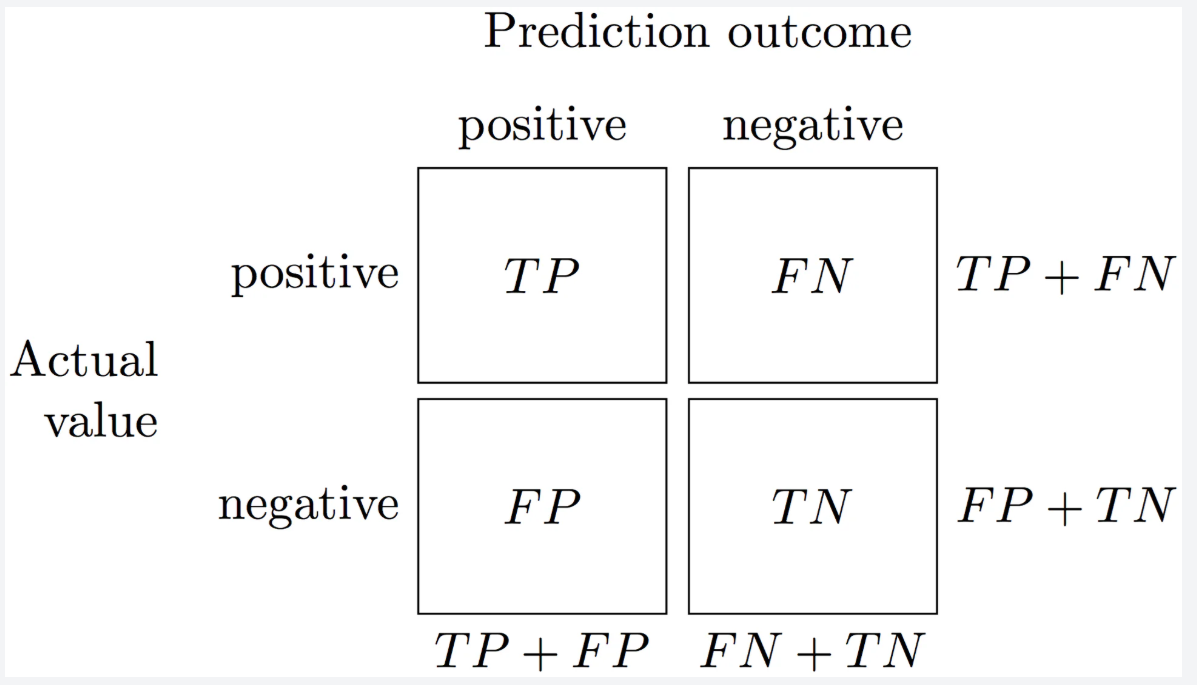

Применение метрик на примере приложения для онлайн-знакомств.

Вам показывают карточки людей. Если человек вам нравится - вы делаете свайп фотографии в одну сторону, если нет - в другую. Если у вас взаимная симпатия - вы можете пообщаться и назначить свидание.

Ключевые показатели:

- Приток новой аудитории
- Отток существующей аудитории
- Метрика денег/покупок
- Метрика удовлетворённости пользователя приложением

Когда мы говорим про внедрение решений, основанных на данных, нужно чтобы баланс между этими метриками оставался в нужном, правильном для анс состоянии.

Нам не нужно чтобы машинное обучение улучшало одно, но полностью рушило другое.

Для каждого человека мы предсказываем правда ли, что ему показывают людей, которые ему понравятся. Значит если пользователю показали понравившееся фото и человеку на фото этот пользователь тоже понравился - это положительный исход.

## Задание

Поупражняемся в расчётах precision. В задании даны переменные, содержащие информацию о песнях и артистах - X_train, y_train, X_test и y_test. Исходно в датасэтах содержались тексты песен, но Decision Tree работает с категориальными и числовыми переменными, а текст это... текст. Поэтому его необходимо преобразовать в понятную для модели форму. В данном случае для каждой песни просто посчитаны длина и количество некоторых знаков пунктуации.

Обучите модель на тренировочных данных, предскажите авторов для тестовых и поместите в переменную predictions. Затем посчитайте precision score на предсказаниях и y_test, укажите параметр average='micro', и сохраните результат в переменную precision.

Если он будет недостаточно высок, потюньте немного модель.

Исходные данные взяты отсюда, слегка процессированные можно взять здесь (исходные колонки типа жанра, года были выкинуты в задании)

In [193]:
df = pd.read_csv('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/songs.csv')

In [194]:
df.head()

,song,year,artist,genre,lyrics,length,commas,exclamations,colons,hyphens
0,the-ownerz,2007,gangstarr,Hip-Hop,"""One-two..""\n""One-two, shots to the chin.. kno...",1300,24,5,0,11
1,dead-sound-of-misery,2006,blind-guardian,Metal,It's dark\nLet's do it now\nBring in the siren...,1566,0,0,0,0
2,modred-s-song,2006,blind-guardian,Metal,I've lost my battle before it starts\nmy first...,996,1,0,1,0
3,the-ninth-wave,2015,blind-guardian,Metal,As dark night embraces\nWe are the nation\nI w...,2868,5,0,0,0
4,skills,2014,gangstarr,Hip-Hop,"Skills, skills, skills\n""My Microphone""\n""It's...",3351,22,0,0,3


In [195]:
df['artist'] = pd.DataFrame(df['artist'].factorize()[0])

In [196]:
df.head()

,song,year,artist,genre,lyrics,length,commas,exclamations,colons,hyphens
0,the-ownerz,2007,0,Hip-Hop,"""One-two..""\n""One-two, shots to the chin.. kno...",1300,24,5,0,11
1,dead-sound-of-misery,2006,1,Metal,It's dark\nLet's do it now\nBring in the siren...,1566,0,0,0,0
2,modred-s-song,2006,1,Metal,I've lost my battle before it starts\nmy first...,996,1,0,1,0
3,the-ninth-wave,2015,1,Metal,As dark night embraces\nWe are the nation\nI w...,2868,5,0,0,0
4,skills,2014,0,Hip-Hop,"Skills, skills, skills\n""My Microphone""\n""It's...",3351,22,0,0,3


In [197]:
df['genre'] = pd.DataFrame(df['genre'].factorize()[0])

In [198]:
y = df['artist']

In [199]:
X = df[['length', 'commas', 'exclamations', 'colons', 'hyphens']]

In [200]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state=0)

In [201]:
clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [202]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [203]:
clf.score(X_train, y_train)

0.8049792531120332

In [204]:
clf.score(X_test, y_test)

0.680672268907563

In [205]:
predictions = clf.predict(X_test)
predictions

array([1, 2, 2, 1, 1, 1, 1, 2, 2, 0, 2, 1, 2, 1, 0, 1, 2, 2, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 2, 0, 2, 1, 1, 0, 2, 2, 1, 1, 0, 2, 1, 2, 1, 2,
       0, 1, 0, 0, 0, 1, 1, 1, 2, 0, 1, 1, 0, 2, 1, 1, 2, 2, 2, 2, 2, 2,
       0, 0, 2, 0, 1, 1, 1, 2, 0, 1, 1, 2, 1, 0, 0, 0, 0, 2, 2, 1, 0, 2,
       0, 1, 1, 0, 2, 2, 2, 0, 0, 0, 1, 1, 1, 1, 1, 2, 0, 0, 0, 2, 0, 2,
       1, 0, 1, 2, 0, 1, 2, 1, 0], dtype=int64)

In [206]:
np.array(y_test)

array([2, 1, 0, 1, 2, 1, 1, 2, 2, 0, 0, 2, 1, 2, 0, 2, 2, 2, 1, 1, 1, 1,
       0, 1, 1, 2, 1, 2, 1, 0, 2, 0, 1, 0, 0, 2, 1, 1, 0, 2, 2, 2, 1, 2,
       1, 1, 0, 0, 0, 1, 1, 1, 2, 0, 2, 0, 0, 0, 2, 2, 2, 2, 2, 2, 1, 0,
       0, 0, 2, 0, 1, 1, 2, 2, 0, 1, 2, 2, 1, 0, 0, 0, 0, 2, 2, 2, 1, 2,
       0, 1, 2, 1, 2, 2, 0, 0, 0, 0, 2, 1, 1, 2, 2, 2, 0, 0, 0, 2, 1, 1,
       1, 2, 1, 2, 0, 1, 2, 1, 0], dtype=int64)

In [207]:
sklearn.metrics.precision_score(y_true = y_test, y_pred=predictions, average='micro')

0.680672268907563

# 2.6 Подбор параметров и ROC and Roll

## Продолжаем титаник

### Загружаем все данные 

In [211]:
with zipfile.ZipFile('titanic.zip') as z:
    with z.open('train.csv') as f: # specify exact path inside ZIP
        df = pd.read_csv(f)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Отбираем X (независимые переменные)

In [213]:
X = df.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'], axis=1)

In [214]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [215]:
X = pd.get_dummies(X, dtype=int)
X

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,38.0,1,0,71.2833,1,0,1,0,0
2,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,0,1,0,0,1
887,1,19.0,0,0,30.0000,1,0,0,0,1
888,3,NaN,1,2,23.4500,1,0,0,0,1
889,1,26.0,0,0,30.0000,0,1,1,0,0


In [216]:
X['Age'].median()

28.0

In [217]:
X['Age'] = X['Age'].fillna(X['Age'].median())

### Отбираем зависимую переменную y

In [219]:
y = df['Survived']

### Делим данные на train и test

In [221]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [222]:
from sklearn.model_selection import GridSearchCV

### Создаем объект модели - дерево решений

In [224]:
clf = sklearn.tree.DecisionTreeClassifier(random_state=0)

### grid_search_cv_clf

In [226]:
parameters = {'criterion':['gini', 'entropy'], 'max_depth': range(1,30)}

GridSearchCV в Scikit-learn выполняет поиск наилучших значений гиперпараметров для модели машинного обучения. Он перебирает все возможные комбинации гиперпараметров и оценивает качество модели на каждой комбинации с использованием кросс-валидации. Это позволяет автоматически настраивать гиперпараметры, улучшая точность модели и уменьшая вероятность переобучения.

In [228]:
grid_search_cv_clf = GridSearchCV(estimator=clf, param_grid=parameters, cv=5)

In [229]:
grid_search_cv_clf

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 30)})

Теперь нужно обучить GridSearchCV

In [231]:
# Обучаем на обучающей выборке. GridSearchCV выдает классификатор с оптимальными параметрами
grid_search_cv_clf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 30)})

In [232]:
best_clf = grid_search_cv_clf.best_estimator_
best_clf

DecisionTreeClassifier(criterion='entropy', max_depth=8, random_state=0)

In [233]:
best_clf.get_params

<bound method BaseEstimator.get_params of DecisionTreeClassifier(criterion='entropy', max_depth=8, random_state=0)>

In [234]:
best_clf.score(X_test, y_test)

0.7932203389830509

### precision_score и recall_score

In [236]:
from sklearn.metrics import precision_score, recall_score

In [237]:
y_pred = best_clf.predict(X_test)

precision_score (FP) - т.е. если (N=0 - не выжил, мы говорим, что чел выжил)

In [239]:
precision_score(y_true = y_test, y_pred=y_pred)

0.8041237113402062

recall_score (FN) - т.е. если (P=1 - выжил, мы говорим, что чел не выжил)

In [241]:
recall_score(y_true = y_test, y_pred=y_pred)

0.65

### Изменение отсечки

In [382]:
y_pred

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0], dtype=int64)

In [401]:
# Вероятность отнесения пассажира к отрицательному или положительному классу
# По отсечке 0.5 наблюдение конвертируется в класс
# Тогда можно менять отсечку в зависимости от целей анализа
y_predicted_prob = best_clf.predict_proba(X_test)
# отобрали
y_predicted_prob

array([[0.8852459 , 0.1147541 ],
       [0.61538462, 0.38461538],
       [0.8852459 , 0.1147541 ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.25      , 0.75      ],
       [0.8852459 , 0.1147541 ],
       [0.25      , 0.75      ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.90196078, 0.09803922],
       [1.        , 0.        ],
       [0.8852459 , 0.1147541 ],
       [0.90196078, 0.09803922],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.69565217, 0.30434783],
       [0.8852459 , 0.1147541 ],
       [1.        , 0.        ],
       [0.8852459 , 0.1147541 ],
       [0.68      , 0.32      ],
       [0.69565217, 0.30434783],
       [0.8852459 , 0.1147541 ],
       [0.8852459 , 0.1147541 ],
       [1.        , 0.        ],
       [0.68      , 0.32      ],
       [0.61538462, 0.38461538],
       [1.        , 0.        ],
       [0.69565217, 0.30434783],
       [0.

<Axes: >

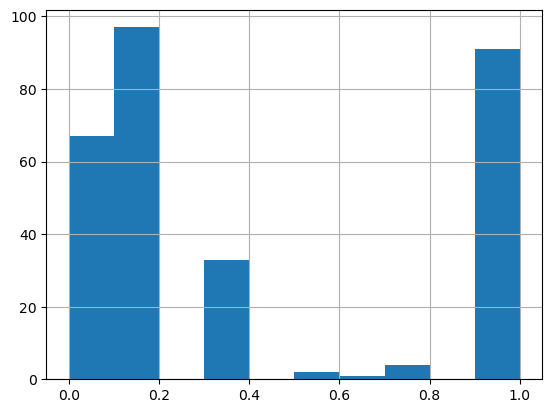

In [393]:
pd.Series(best_clf.predict_proba(X_test)[:, 1]).hist()

График распределения вероятности выжить (класс 1)  
Видим, что довольно много наблюдений в начале и конце. Немного попадают в пограничное (около 0.5) состояние.

In [621]:
# Если вероятность выжить больше 0.8, то присваиваем класс - 1, иначе 0. В таком случае должен быть высокий Precision и низкий Recall
y_pred_new = np.where(y_predicted_prob[:, 1] > 0.3, 1, 0)
y_pred_new

array([0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0])

In [623]:
precision_score(y_test, y_pred_new)

0.7480916030534351

In [625]:
recall_score(y_test, y_pred_new)

0.8166666666666667

In [627]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_new).ravel()
tn, fp, fn, tp

(142, 33, 22, 98)

In [629]:
# посчитать долю тру негатив от всех негативов (это TN + те негативы, которые мы посчитали как позитивы)
spec = tn/(tn+fp)
spec

0.8114285714285714

In [631]:
fpr = 1 - spec
fpr

0.1885714285714286

In [423]:
# Если вероятность выжить больше 0.2, то присваиваем класс - 1, иначе 0. В таком случае должен быть низкий Precision и высокий Recall
y_pred_new = np.where(y_predicted_prob[:, 1] > 0.2, 1, 0)
y_pred_new

array([0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0])

In [425]:
precision_score(y_test, y_pred_new)

0.7480916030534351

In [427]:
recall_score(y_test, y_pred_new)

0.8166666666666667

## ROC кривая

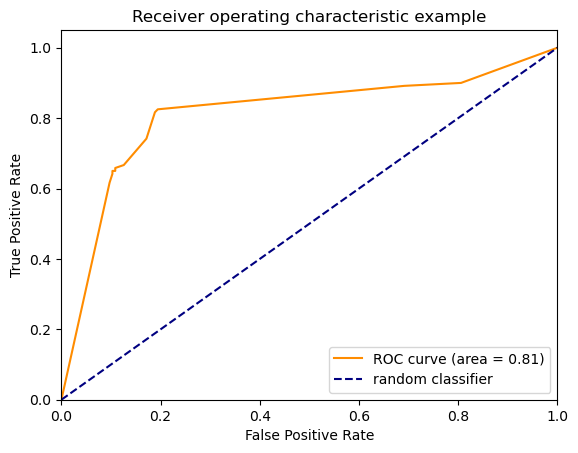

In [510]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_predicted_prob[:,1])
roc_auc= auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange',
         label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

ROC-кривая — это график, который показывает зависимость между чувствительностью (Recall) и специфичностью (1 — False Positive Rate) при различных порогах классификации. Площадь под ROC-кривой (AUC-ROC) является количественной характеристикой качества бинарной классификации и может принимать значения от 0 до 1. Чем выше значение AUC-ROC, тем лучше работает модель.

Интерпретация ROC-кривой: Пунктирная линия - это различные варианты порога классификации (отсечки). Начинаем смотреть сверху вниз. Вверху значение отсечки низкое (например, 0.05). Тогда TPR(высокий), тк мы практически всех относим к выжившим, но FPR тоже высокий, тк много негатив наблюдений (N) попадает в позитив (P). По мере снижения вниз значение отсечки увеличивается, TPR снижается, FPR тоже снижается.

`ROC кривая нивелирует дисбаланс классов`

In [456]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

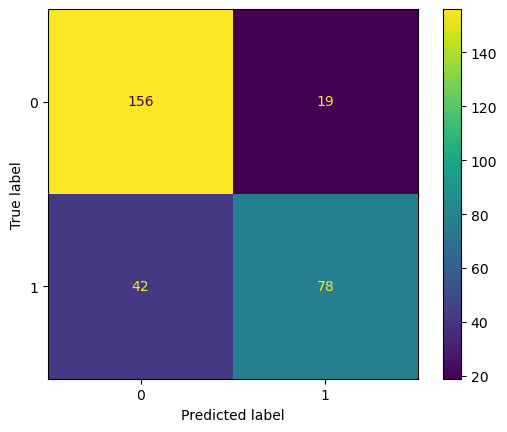

In [460]:
cm = sklearn.metrics.confusion_matrix(y_true = y_test, y_pred = y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# 2.7 Практика

## Алгоритм дерева решений

По умолчанию классификатор строит настолько глубокое дерево, насколько позволяет набор данных. Таким образом, классификатор преследует цель безошибочно отнести к нужному классу все объекты в выборке. Такой "жадный" алгоритм может приводить к переобучению в результате избыточной глубины дерева.

Проверить насколько сильно переобучен классификатор можно обучив его на обучающей выборке затем проверить качество модели на тестовой выборке.
Основная цель построения любой модели - получить классификатор с максимальной обобщающей способностью, т.е. такой классификатор, который успешно выделяет общие закономерности и не переобучается на частных закономерностях в конкретной выборке.

Для этой цели мы подбираем оптимальный набор параметров классификатора, в случае дерева решений - это может быть глубина дерева. Для выбора оптимального параметра можно построить множество деревьев с разной глубиной и выбрать наилучший результат.

В качестве критерия "наилучшего" классификатора можно использовать кросс-валидацию. При таком подходе данные в выборке разбиваются на n частей, например на 5 частей, далее классификатор обучается на 4 частях данных и валидируется на оставшейся 5ой части. Затем операция повторяется, чтобы каждая из 5 частей данных оказалась в роли тестового множества.

## Задание 1

Начнём с простого - создайте Decision Tree классификатор, используя одноимённый класс из библиотеки sklearn и сохраните его в переменную dt.

У дерева должны быть следующие параметры:
- максимальная глубина - 5 уровней
- минимальное число образцов в вершине для разделения - 5

min_samples_split - с помощью этого параметра мы задаём, какое минимальное количество элементов должно остаться в очередной ветке дерева, чтобы алгоритм считал, что эту ветку всё ещё можно продолжать разделять. Стандартное значение этого параметра равно двум, что естественно: пока в ветке есть хотя бы два элемента разных классов, мы можем продолжать искать способ разделить их. Однако, мы можем увеличить этот параметр, например, до трёх. Тогда ветка с двумя элементами уже будет считаться неразделимой. Тут мы теряем в точности на тренеровочной выборке, потому что возникает вероятность того, что в одной такой ветке останутся элементы разных классов, но зато мы выигрываем в генерализации (возможно) и интерпретируемости, так как рост дерева вглубину ограничивается и оно становится проще. 

In [646]:
dt = sklearn.tree.DecisionTreeClassifier(max_depth=5, min_samples_split = 5)

## Задание 2

Представьте, что при помощи дерева решений мы хотим классифицировать есть или нет у пациента заболевание сердца (переменная num), основываясь на двух признаках: пол (sex) и наличие/отсутсвие стенокардии (exang). 

Обучите дерево решений на этих данных, используйте entropy в качестве критерия.

Укажите, чему будет равняться значение Information Gain для переменной,  которая будет помещена в корень дерева.

In [649]:
num_df = pd.read_csv('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/train_data_tree.csv')

In [656]:
num_df.head()

,sex,exang,num
0,1,1,1
1,1,1,1
2,1,0,1
3,1,0,0
4,1,0,1


In [658]:
X = num_df[['sex', 'exang']]

In [668]:
y = num_df['num']

In [670]:
clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy')

In [672]:
clf.fit(X, y)

DecisionTreeClassifier(criterion='entropy')

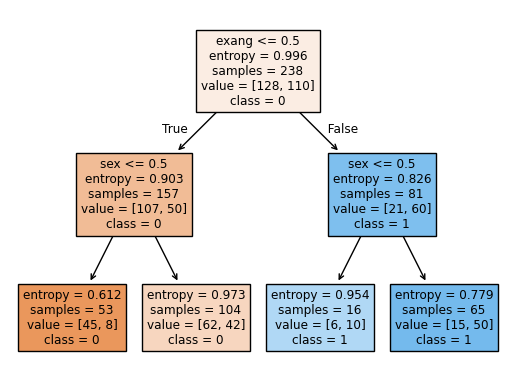

In [674]:
sklearn.tree.plot_tree(clf, feature_names=list(X),
                       class_names=['0', '1'],
                       filled=True);

In [693]:
# энтропия для каждого узла (ветки дерева)
entropy = clf.tree_.impurity
entropy

array([0.99587   , 0.90271134, 0.61219613, 0.97315604, 0.82562653,
       0.954434  , 0.77934984])

Information Gain:

$\Large IG(Q) = S_O - \sum_{i=1}^{q}\frac{N_i}{N}S_i,$  
где $q$ – число групп после разбиения, $N_i$ – число элементов выборки, у которых признак $Q$ имеет $i$-ое значение

In [697]:
# количество сэмплов(рассматриваемых вариантов) каждой ветки дерева
n = clf.tree_.n_node_samples
n

array([238, 157,  53, 104,  81,  16,  65], dtype=int64)

In [699]:
entropy[0] - (n[1]/n[0]*entropy[1] + n[4]/n[0]*entropy[4])

0.11939340343891591

In [741]:
clf.tree_.children_left

array([ 1,  2, -1, -1,  5, -1, -1], dtype=int64)

In [743]:
clf.tree_.children_right

array([ 4,  3, -1, -1,  6, -1, -1], dtype=int64)

In [725]:
l_node = clf.tree_.children_left[0] # индекс корня левого поддерева
l_node

1

In [731]:
r_node = clf.tree_.children_right[0] # индекс корня правого поддерева
r_node

4

In [727]:
n1 = clf.tree_.n_node_samples[l_node] # сэмплов в левом поддереве
n1

157

In [733]:
n2 = clf.tree_.n_node_samples[r_node] # сэмплов в правом поддереве
n2

81

In [729]:
e1 = clf.tree_.impurity[l_node] # энтропия в корне левого поддерева
e1

0.9027113410339267

## Задание 5

In [756]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris


iris = load_iris()
X = iris.data
y = iris.target

Для начала опробуем наше дерево на классическом наборе iris, где собраны данные о длине, ширине чашелистиков и лепестков ирисов и их принадлежности к виду. В sklearn он уже встроен, что довольно удобно.

Итак, вам даны 2 numpy эррея с измеренными признаками ирисов и их принадлежностью к виду. Сначала попробуем примитивный способ с разбиением данных на 2 датасэта. Используйте функцию train_test_split для разделения имеющихся данных на тренировочный и тестовый наборы данных, 75% и 25% соответственно.

Затем создайте дерево dt с параметрами по умолчанию и обучите его на тренировочных данных, а после предскажите классы, к которым принадлежат данные из тестовой выборки, сохраните результат предсказаний в переменную predicted.

In [763]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [765]:
dt = DecisionTreeClassifier()

In [769]:
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [780]:
predicted = dt.predict(X_test)
predicted

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0])

In [775]:
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0])

## Задание 8

Одно дерево - хорошо, но где гарантии, что оно является лучшим, или хотя бы близко к нему? Одним из способов найти более-менее оптимальный набор параметров дерева является перебор множества деревьев с разными параметрами и выбор подходящего.
Для этой цели существует класс GridSearchCV, перебирающий каждое из сочетаний параметров среди заданных для модели, обучающий её на данных и проводящих кросс-валидацию. После этого в аттрибуте .best_estimator_ храниться модель с лучшими параметрами.
Это применимо не только к деревьям, но и к другим моделям sklearn.

Теперь задание - осуществите перебор всех деревьев на данных ириса по следующим параметрам:
максимальная глубина - от 1 до 10 уровней  
минимальное число проб для разделения - от 2 до 10  
минимальное число проб в листе - от 1 до 10  
и сохраните в переменную best_tree лучшее дерево. Переменную с GridSearchCV назовите search

In [786]:
from sklearn.model_selection import GridSearchCV

In [788]:
iris = load_iris()
X = iris.data
y = iris.target

In [792]:
parameters = {'min_samples_split':range(2, 10), 'min_samples_leaf':range(1, 10), 'max_depth': range(1,10)}

In [790]:
clf = sklearn.tree.DecisionTreeClassifier(random_state=0)

In [798]:
search = GridSearchCV(estimator=clf, param_grid=parameters)
search

GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': range(1, 10),
                         'min_samples_leaf': range(1, 10),
                         'min_samples_split': range(2, 10)})

In [800]:
search.fit(X, y)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': range(1, 10),
                         'min_samples_leaf': range(1, 10),
                         'min_samples_split': range(2, 10)})

In [805]:
best_tree = search.best_estimator_
best_tree

DecisionTreeClassifier(max_depth=4, random_state=0)

## Задание 9 

Чем больше данных, сложность модели и число её параметров, тем дольше будет вестись поиск GridSearchCV. Однако бывают случаи, когда модель нужна здесь и сейчас, и для этого есть RandomizedSearchCV! Пробегаясь по рандомной подвыборке параметров, он ищет наиболее хорошую модель и делает это быстрее полного перебора параметров, хотя и может пропустить оптимальные параметры.

In [811]:
from sklearn.model_selection import RandomizedSearchCV

In [813]:
clf = DecisionTreeClassifier(random_state=0)

In [815]:
parameters = {'min_samples_split':range(2, 10), 'min_samples_leaf':range(1, 10), 'max_depth': range(1,10)}
search = RandomizedSearchCV(estimator=clf, param_distributions=parameters)
search

RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=0),
                   param_distributions={'max_depth': range(1, 10),
                                        'min_samples_leaf': range(1, 10),
                                        'min_samples_split': range(2, 10)})

In [817]:
search.fit(X, y)

RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=0),
                   param_distributions={'max_depth': range(1, 10),
                                        'min_samples_leaf': range(1, 10),
                                        'min_samples_split': range(2, 10)})

In [819]:
best_tree = search.best_estimator_
best_tree

DecisionTreeClassifier(max_depth=7, min_samples_leaf=3, min_samples_split=7,
                       random_state=0)

## Задание 10

In [ ]:
# разбиваем датафрейм train на X и y
x_train = train.drop(["y"], axis=1)
y_train = train["y"]

# создаем словарь с параметрами, которые хотим проверить
params = {"max_depth": range(1,11), "min_samples_split":range(2,11), "min_samples_leaf":range(1,11)}

# создаем экзмпляр дерева
dt = DecisionTreeClassifier()

# создаем экземпляр GridSearchCV
search = GridSearchCV(dt, params, cv=5)

# обучаем или ищем лучшее дерево
search.fit(x_train,y_train)

# сохраням лучшее дерево по мнению GridSearchCV
best_tree = search.best_estimator_

# делаем предсказания по лучшему дереву на датасете test
predictions = best_tree.predict(test)